In [47]:
import matplotlib.pyplot as plt

try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")

print("libraries successfully imported")

libraries successfully imported


In [49]:
#old data qubits carrying the state
d0, d1 = cirq.LineQubit.range(2)

#fresh qubits that receive the teleported state
t0, t1 = cirq.LineQubit.range(2, 4)

#ancilla for the weight-4 Z measurement
a0 = cirq.LineQubit(4)

In [50]:
#choose the phase error to test
error_location = "d1"

#possible Z errors
phase_errors = {
    "none": None,
    "d0": cirq.Z(d0),
    "d1": cirq.Z(d1)
}

In [51]:
circuit = cirq.Circuit()

#prepare the old data in |++>
circuit.append(cirq.H(d0))
circuit.append(cirq.H(d1))

#prepare the fresh qubits in |++>
circuit.append(cirq.H(t0))
circuit.append(cirq.H(t1))

#add the chosen phase error
selected_error = phase_errors[error_location]

if selected_error is not None:
    circuit.append(selected_error)

print("starting circuit:")
print(circuit)

starting circuit:
0: ───H───────

1: ───H───Z───

2: ───H───────

3: ───H───────


In [52]:
#prepare the parity ancilla in |+>
circuit.append(cirq.H(a0))

#map Z0 Z1 Z2 Z3 parity onto the ancilla
circuit.append(cirq.CZ(a0, d0))
circuit.append(cirq.CZ(a0, d1))
circuit.append(cirq.CZ(a0, t0))
circuit.append(cirq.CZ(a0, t1))

#measure the ancilla in the X basis
circuit.append(cirq.H(a0))
circuit.append(cirq.measure(a0, key="z4"))

print("after the weight-4 Z measurement:")
print(circuit)

after the weight-4 Z measurement:
          ┌──┐
0: ───H─────@──────────────────────────────
            │
1: ───H────Z┼────@─────────────────────────
            │    │
2: ───H─────┼────┼───@─────────────────────
            │    │   │
3: ───H─────┼────┼───┼───@─────────────────
            │    │   │   │
4: ───H─────@────@───@───@───H───M('z4')───
          └──┘


In [53]:
#measure the old data in the X basis
circuit.append(cirq.H(d0))
circuit.append(cirq.H(d1))

circuit.append(cirq.measure(d0, key="m1"))
circuit.append(cirq.measure(d1, key="m2"))

print("full CZ parity gadget:")
print(circuit)

full CZ parity gadget:
          ┌──┐
0: ───H─────@────H───M('m1')───────────────────────────
            │
1: ───H────Z┼────@───H─────────M('m2')─────────────────
            │    │
2: ───H─────┼────┼───@─────────────────────────────────
            │    │   │
3: ───H─────┼────┼───┼─────────@───────────────────────
            │    │   │         │
4: ───H─────@────@───@─────────@─────────H───M('z4')───
          └──┘


In [54]:
sim = cirq.Simulator()

result = sim.run(circuit, repetitions=1)

z4 = int(result.measurements["z4"][0][0])
m1 = int(result.measurements["m1"][0][0])
m2 = int(result.measurements["m2"][0][0])

print("weight-4 Z result:", z4)
print("first X result:", m1)
print("second X result:", m2)

weight-4 Z result: 1
first X result: 1
second X result: 0


In [55]:
#the paper combines the two X measurements with XOR
x_parity = m1 ^ m2

measurement_results = {
    "z4": z4,
    "m1": m1,
    "m2": m2,
    "x_parity": x_parity
}

print("measurement results:", measurement_results)
print("X-parity result:", x_parity)

measurement results: {'z4': 1, 'm1': 1, 'm2': 0, 'x_parity': 1}
X-parity result: 1


In [57]:
#keep track of corrections instead of immediately applying gates
pauli_frame = {
    "t0": {
        "x_update": z4,
        "z_update": m1
    },
    "t1": {
        "x_update": 0,
        "z_update": m2
    }
}

print("Pauli-frame information:")
print(pauli_frame)

Pauli-frame information:
{'t0': {'x_update': 1, 'z_update': 1}, 't1': {'x_update': 0, 'z_update': 0}}


In [58]:
counts = {
    "even": 0,
    "odd": 0
}

for shot in range(1000):
    result = sim.run(circuit, repetitions=1)

    m1 = int(result.measurements["m1"][0][0])
    m2 = int(result.measurements["m2"][0][0])

    x_parity = m1 ^ m2

    if x_parity == 0:
        counts["even"] += 1
    else:
        counts["odd"] += 1

print("parity counts:", counts)

parity counts: {'even': 0, 'odd': 1000}


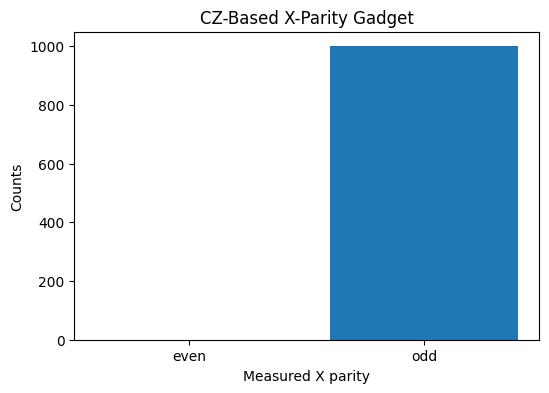

In [59]:
labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.xlabel("Measured X parity")
plt.ylabel("Counts")
plt.title("CZ-Based X-Parity Gadget")
plt.show()